In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install praat-parselmouth librosa xgboost shap -q
print("✅ 完成")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 114.1 MB/s eta 0:00:00
✅ 完成


In [ ]:
import os
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

BASE_DIR     = '/content/drive/MyDrive/voice_age_project_0428/voice_age_project_0428'
OUTPUT_CSV   = os.path.join(BASE_DIR, 'features.csv')
DEMO_CSV     = os.path.join(BASE_DIR, 'VideoDemographics.csv')

print("✅ 設定完成")

✅ 設定完成


In [ ]:
# 直接用之前跑了2小時的 features.csv，不需要重新提取
feature_df = pd.read_csv(OUTPUT_CSV)
demo_df    = pd.read_csv(DEMO_CSV)

# 合併年齡標籤
merged_df = feature_df.merge(
    demo_df[['ActorID', 'Age']],
    on='ActorID',
    how='inner'
)

print(f"合併後筆數：{len(merged_df)}")
print(f"年齡範圍：{merged_df['Age'].min()} – {merged_df['Age'].max()} 歲")


合併後筆數：7442
年齡範圍：20 – 74 歲


二元分類組別分佈：
AgeGroup
Below 51        6048
51 and Above    1394
Name: count, dtype: int64

總計：7442 筆


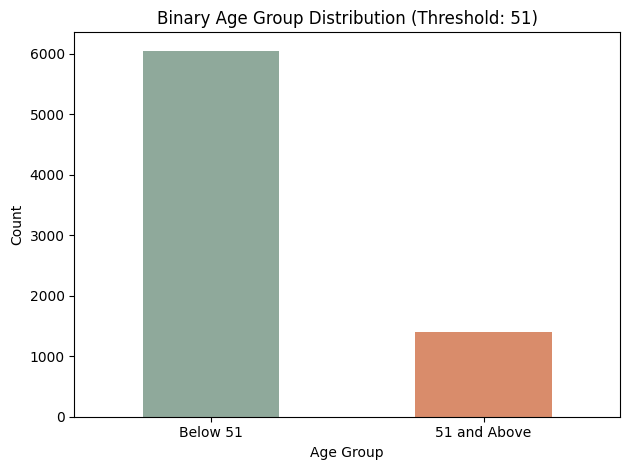

In [ ]:
C_SAGE   = '#8FA99B'
C_ORANGE = '#D98C6B'

def age_to_binary(age):
    return 'Below 51' if age < 51 else '51 and Above'

merged_df['AgeGroup'] = merged_df['Age'].apply(age_to_binary)

print("二元分類組別分佈：")
print(merged_df['AgeGroup'].value_counts())
print(f"\n總計：{len(merged_df)} 筆")

merged_df['AgeGroup'].value_counts().plot(
    kind='bar',
    color=[C_SAGE, C_ORANGE]
)
plt.title('Binary Age Group Distribution (Threshold: 51)')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



In [ ]:
feature_cols = ['F0_mean', 'Jitter', 'Shimmer', 'HNR'] + \
               [f'MFCC_{i}' for i in range(2, 14)]  # 從 2 開始，跳過 MFCC_1

X     = merged_df[feature_cols].values
y_raw = merged_df['AgeGroup'].values

le = LabelEncoder()
y  = le.fit_transform(y_raw)
print(f"標籤對應：{dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"特徵數量：{len(feature_cols)} 維（移除 MFCC_1）")

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"訓練集：{X_train.shape[0]} 筆")
print(f"測試集：{X_test.shape[0]} 筆")

標籤對應：{'51 and Above': np.int64(0), 'Below 51': np.int64(1)}
特徵數量：16 維（移除 MFCC_1）
訓練集：5953 筆
測試集：1489 筆


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest（二元分類）===")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

=== Random Forest（二元分類）===
              precision    recall  f1-score   support

51 and Above       0.53      0.41      0.47       279
    Below 51       0.87      0.92      0.89      1210

    accuracy                           0.82      1489
   macro avg       0.70      0.66      0.68      1489
weighted avg       0.81      0.82      0.81      1489



In [ ]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("=== XGBoost（二元分類）===")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

=== XGBoost（二元分類）===
              precision    recall  f1-score   support

51 and Above       0.83      0.33      0.48       279
    Below 51       0.86      0.98      0.92      1210

    accuracy                           0.86      1489
   macro avg       0.85      0.66      0.70      1489
weighted avg       0.86      0.86      0.84      1489



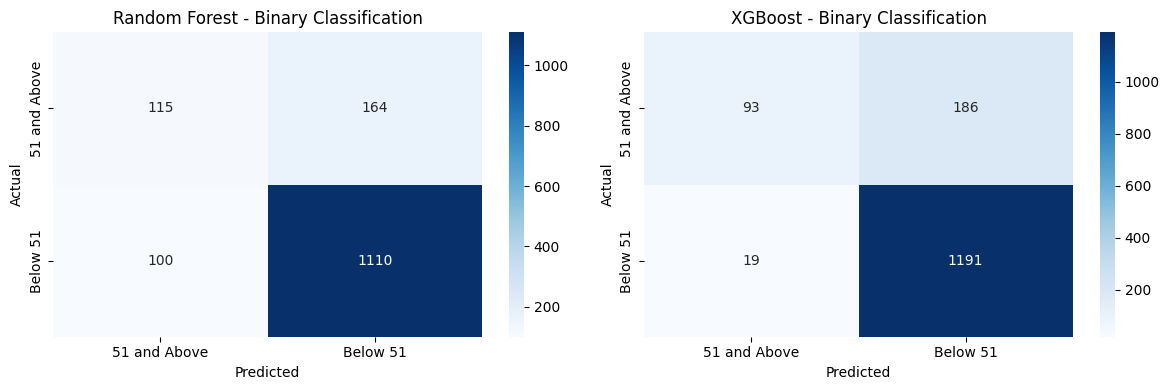

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, y_pred) in zip(axes, [
    ('Random Forest', y_pred_rf),
    ('XGBoost',       y_pred_xgb)
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_, ax=ax)
    ax.set_title(f'{name} - Binary Classification')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'confusion_matrix_binary.png'), dpi=150)
plt.show()

shap_values shape: (1489, 16)
le.classes_: ['51 and Above' 'Below 51']


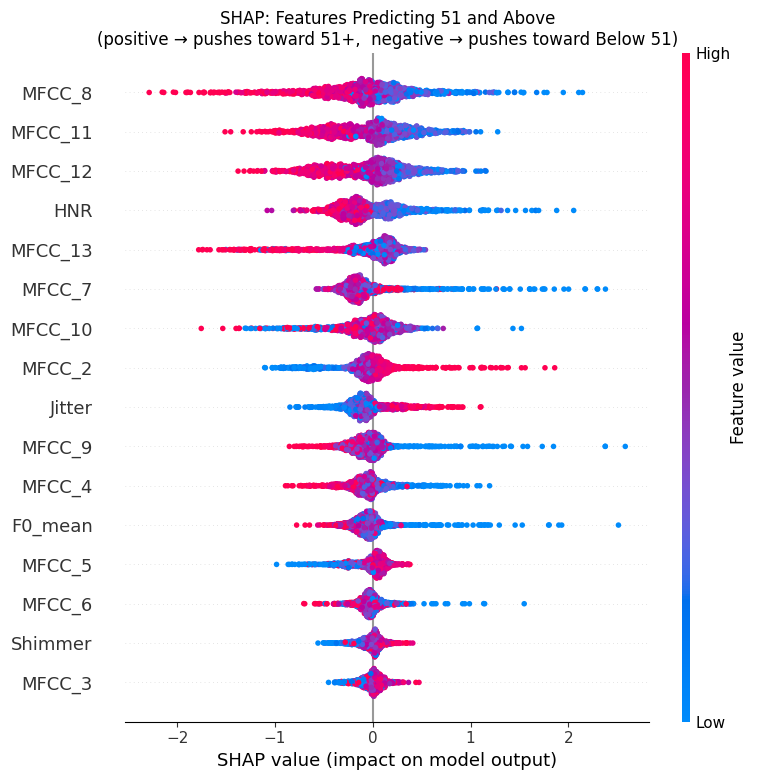

In [ ]:
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print(f"shap_values shape: {shap_values.shape}")
print(f"le.classes_: {le.classes_}")

# 用 Below 51（class 1）的 SHAP 值取負數
# 讓正值代表「推向 51 歲以上」，符合醫學理論閱讀方向
below_idx = list(le.classes_).index('Below 51')

if shap_values.ndim == 3:
    shap_plot = -shap_values[:, :, below_idx]
elif shap_values.ndim == 2:
    shap_plot = -shap_values

plt.figure()
shap.summary_plot(
    shap_plot,
    X_test,
    feature_names=feature_cols,
    show=False
)
plt.title('SHAP: Features Predicting 51 and Above\n(positive → pushes toward 51+,  negative → pushes toward Below 51)')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'shap_binary.png'), dpi=150)
plt.show()

In [ ]:
import pickle

binary_artifacts = {
    'xgb_model':     xgb_model,
    'rf_model':      rf_model,
    'scaler':        scaler,
    'label_encoder': le,
    'feature_cols':  feature_cols
}

with open(os.path.join(BASE_DIR, 'model_artifacts_binary.pkl'), 'wb') as f:
    pickle.dump(binary_artifacts, f)

print("✅ 二元分類模型已儲存")

✅ 二元分類模型已儲存
